DenseNet121 Training (Step-by-step)

In [1]:
import os, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("TensorFlow:", tf.__version__)
tf.random.set_seed(42)
np.random.seed(42)


TensorFlow: 2.13.0


In [2]:
TRAIN_DIR = "../dataset/train"
VAL_DIR   = "../dataset/validation"
TEST_DIR  = "../dataset/test"

IMG_SIZE = 224
BATCH_SIZE = 8  # CPU-safe


Cell 3 — Preprocessing for DenseNet121 (CT + densenet preprocess_input)

In [3]:
import cv2
from tensorflow.keras.applications.densenet import preprocess_input

def densenet_preprocessing(img):
    img = img.astype(np.uint8)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray = clahe.apply(gray)

    gray = cv2.GaussianBlur(gray, (3,3), 0)

    x = np.stack([gray, gray, gray], axis=-1).astype(np.float32)

    # DenseNet expected preprocessing
    x = preprocess_input(x)

    return x


In [4]:
train_gen = ImageDataGenerator(
    preprocessing_function=densenet_preprocessing,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    brightness_range=(0.9, 1.1),
    horizontal_flip=True
)

val_gen  = ImageDataGenerator(preprocessing_function=densenet_preprocessing)
test_gen = ImageDataGenerator(preprocessing_function=densenet_preprocessing)

train_data = train_gen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode="binary"
)

val_data = val_gen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode="binary"
)

test_data = test_gen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode="binary",
    shuffle=False
)

print("Class indices:", train_data.class_indices)


Found 1843 images belonging to 2 classes.
Found 235 images belonging to 2 classes.
Found 437 images belonging to 2 classes.
Class indices: {'Normal': 0, 'Stroke': 1}


In [5]:
class_weights = {0: 0.8477460901563938, 1: 1.218915343915344}
class_weights


{0: 0.8477460901563938, 1: 1.218915343915344}

Cell 6 — Build DenseNet121 Model (Frozen Backbone)

In [6]:
base = DenseNet121(
    include_top=False,
    weights="imagenet",
    input_tensor=Input(shape=(IMG_SIZE, IMG_SIZE, 3))
)

base.trainable = False  # phase-1

x = base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)
out = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base.input, outputs=out)
model.summary()


29084464/29084464 [==============================] - 9s 0us/step
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 zero_padding2d (ZeroPaddin  (None, 230, 230, 3)          0         ['input_1[0][0]']             
 g2D)                                                                                             
                                                                                                  
 conv1/conv (Conv2D)         (None, 112, 112, 64)         9408      ['zero_padding2d[0][0]']      
                                                                                                  
 conv1/bn (BatchNormalizati  

In [7]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)


In [8]:
os.makedirs("../models", exist_ok=True)

callbacks = [
    ModelCheckpoint(
        "../models/densenet121_best.h5",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
]


In [9]:
EPOCHS = 25

history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/25
231/231 [==============================] - ETA: 0s - loss: 0.7595 - accuracy: 0.5149 - precision: 0.4223 - recall: 0.4960 - auc: 0.5265
Epoch 1: val_auc improved from -inf to 0.62347, saving model to ../models\densenet121_best.h5


c:\Users\admin\Desktop\Brain_Stroke_Project\stroke_env\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


231/231 [==============================] - 254s 1s/step - loss: 0.7595 - accuracy: 0.5149 - precision: 0.4223 - recall: 0.4960 - auc: 0.5265 - val_loss: 0.6636 - val_accuracy: 0.5957 - val_precision: 0.3924 - val_recall: 0.3974 - val_auc: 0.6235 - lr: 1.0000e-04
Epoch 2/25
231/231 [==============================] - ETA: 0s - loss: 0.6863 - accuracy: 0.5779 - precision: 0.4878 - recall: 0.5807 - auc: 0.5992
Epoch 2: val_auc improved from 0.62347 to 0.64523, saving model to ../models\densenet121_best.h5
231/231 [==============================] - 329s 1s/step - loss: 0.6863 - accuracy: 0.5779 - precision: 0.4878 - recall: 0.5807 - auc: 0.5992 - val_loss: 0.6955 - val_accuracy: 0.5191 - val_precision: 0.3856 - val_recall: 0.7564 - val_auc: 0.6452 - lr: 1.0000e-04
Epoch 3/25
231/231 [==============================] - ETA: 0s - loss: 0.6845 - accuracy: 0.5654 - precision: 0.4757 - recall: 0.5833 - auc: 0.5968
Epoch 3: val_auc improved from 0.64523 to 0.70121, saving model to ../models\densen

In [10]:
test_metrics = model.evaluate(test_data, verbose=1)
print(dict(zip(model.metrics_names, test_metrics)))


55/55 [==============================] - 48s 863ms/step - loss: 0.4698 - accuracy: 0.7620 - precision: 0.5813 - recall: 0.7154 - auc: 0.8322
{'loss': 0.46975651383399963, 'accuracy': 0.7620137333869934, 'precision': 0.581250011920929, 'recall': 0.7153846025466919, 'auc': 0.8321723937988281}


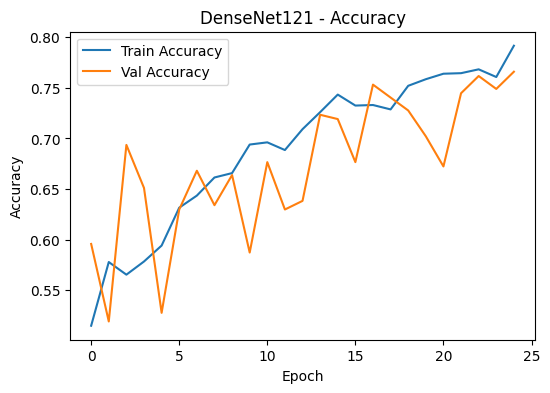

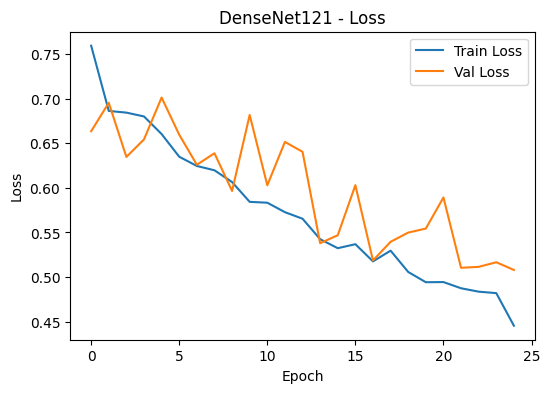

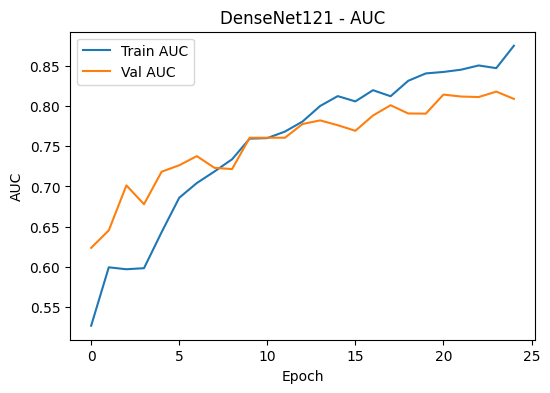

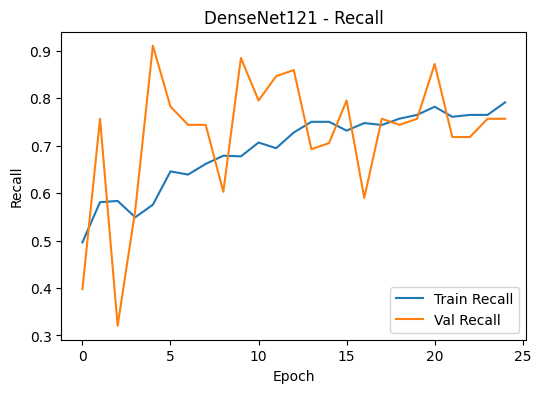

In [11]:
import matplotlib.pyplot as plt

def plot_history_metrics(history, title_prefix="DenseNet121"):
    h = history.history
    
    # Accuracy
    plt.figure(figsize=(6,4))
    plt.plot(h["accuracy"], label="Train Accuracy")
    plt.plot(h["val_accuracy"], label="Val Accuracy")
    plt.title(f"{title_prefix} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    # Loss
    plt.figure(figsize=(6,4))
    plt.plot(h["loss"], label="Train Loss")
    plt.plot(h["val_loss"], label="Val Loss")
    plt.title(f"{title_prefix} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    # AUC
    plt.figure(figsize=(6,4))
    plt.plot(h["auc"], label="Train AUC")
    plt.plot(h["val_auc"], label="Val AUC")
    plt.title(f"{title_prefix} - AUC")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.legend()
    plt.show()

    # Recall
    plt.figure(figsize=(6,4))
    plt.plot(h["recall"], label="Train Recall")
    plt.plot(h["val_recall"], label="Val Recall")
    plt.title(f"{title_prefix} - Recall")
    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.legend()
    plt.show()

# Use the correct history variable name
plot_history_metrics(history1, "DenseNet121")


In [12]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

test_data.reset()

y_prob = model.predict(test_data, verbose=1)
y_pred = (y_prob >= 0.5).astype(int).ravel()
y_true = test_data.classes

print(classification_report(y_true, y_pred, target_names=["Normal", "Stroke"]))


55/55 [==============================] - 44s 731ms/step
              precision    recall  f1-score   support

      Normal       0.87      0.78      0.82       307
      Stroke       0.58      0.72      0.64       130

    accuracy                           0.76       437
   macro avg       0.72      0.75      0.73       437
weighted avg       0.78      0.76      0.77       437



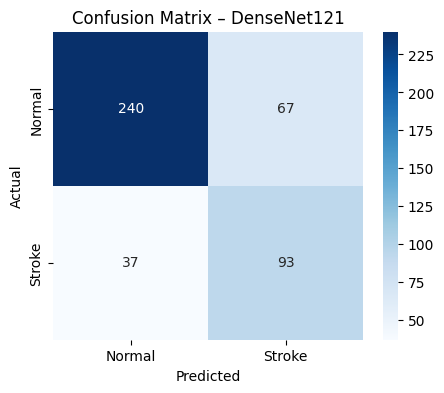

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Normal", "Stroke"],
    yticklabels=["Normal", "Stroke"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – DenseNet121")
plt.show()


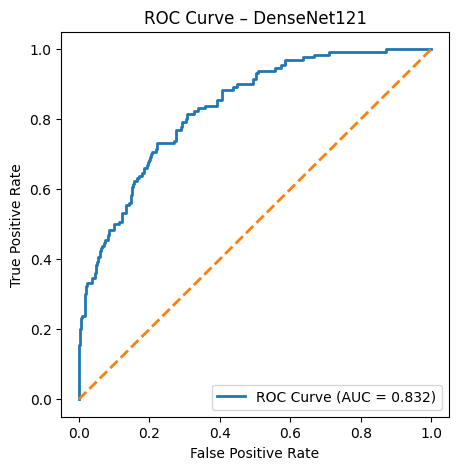

AUC: 0.8321473314958656


In [14]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, lw=2, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – DenseNet121")
plt.legend(loc="lower right")
plt.show()

print("AUC:", roc_auc)


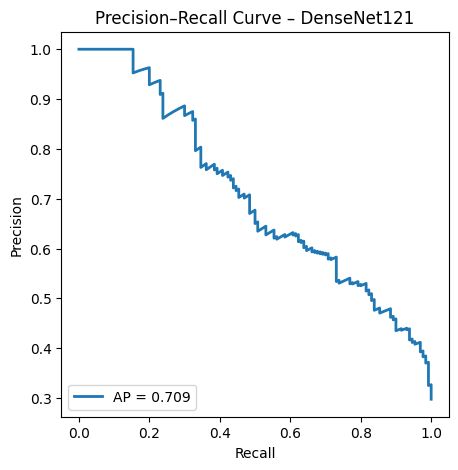

Average Precision (AP): 0.7089985436192943


In [15]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_true, y_prob)
ap = average_precision_score(y_true, y_prob)

plt.figure(figsize=(5,5))
plt.plot(recall, precision, lw=2, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – DenseNet121")
plt.legend(loc="lower left")
plt.show()

print("Average Precision (AP):", ap)
